<a href="https://colab.research.google.com/github/dhanalaxmi366-cmd/banking_insurance_data_engineering/blob/main/Capstone_Banking_Dhanalakshmi_Subramanian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd

# Verify it is working
print("Pandas version:", pd.__version__)
print("Ready to go!")

Pandas version: 2.2.2
Ready to go!


In [30]:
# Upload the CSV file (click the button that appears)
from google.colab import files
uploaded = files.upload()

Saving Capstone_combine_Transactions.csv to Capstone_combine_Transactions (3).csv
Saving Capstone_monthly_Trends.csv.csv to Capstone_monthly_Trends.csv (3).csv


In [31]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head(5)


,Transaction_ID,Transaction_Date,Amount,Channel,Transaction_Type,Branch,Status,Customer_ID,Customer_Name,City,Account_Type,Account_Open_Date
0,TXN-010261,2025-03-20,176.58,Mobile,Payment,University,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05
1,TXN-012130,2025-01-06,119.29,ATM,Deposit,Midtown,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05
2,TXN-013083,2025-08-23,1342.90,ATM,Fee,University,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05
3,TXN-013140,2025-08-10,37111.82,Online,Withdrawal,Eastside,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05
4,TXN-016776,2025-03-17,197.72,Online,Fee,Downtown,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05


In [32]:

import pandas as pd

# Clean column names
df.columns = df.columns.str.strip()
df['Transaction_Month'] = pd.to_datetime(df['Transaction_Date']).dt.month

# Rename columns
df = df.rename(columns={
    'Transaction_Month':'Month',
    'Transaction_count': 'Transaction_Count',
    'Total_volume': 'Total_Volume'
})
print(df.columns.tolist())
df['Month'] = df['Month'].astype(int)
# Convert Month to int

# Preview data
df.head()

['Transaction_ID', 'Transaction_Date', 'Amount', 'Channel', 'Transaction_Type', 'Branch', 'Status', 'Customer_ID', 'Customer_Name', 'City', 'Account_Type', 'Account_Open_Date', 'Month']


,Transaction_ID,Transaction_Date,Amount,Channel,Transaction_Type,Branch,Status,Customer_ID,Customer_Name,City,Account_Type,Account_Open_Date,Month
0,TXN-010261,2025-03-20,176.58,Mobile,Payment,University,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,3
1,TXN-012130,2025-01-06,119.29,ATM,Deposit,Midtown,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,1
2,TXN-013083,2025-08-23,1342.90,ATM,Fee,University,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,8
3,TXN-013140,2025-08-10,37111.82,Online,Withdrawal,Eastside,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,8
4,TXN-016776,2025-03-17,197.72,Online,Fee,Downtown,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,3


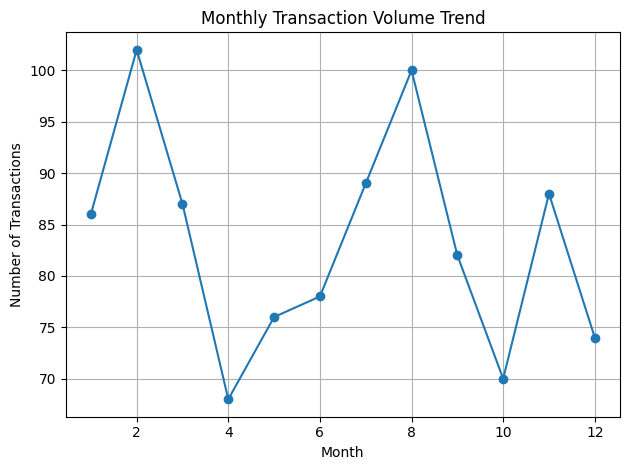

In [35]:
import matplotlib.pyplot as plt


#clean out any duplicate column
df = df.loc[:,~df.columns.duplicated()]

#Group and count using standard.count method
monthly_df = df.groupby('Month', as_index =False)['Transaction_ID'].count()
monthly_df = monthly_df.rename(columns ={'Transaction_ID': 'Transaction_Count'})
monthly_df = (
    df.groupby('Month')
      .size()
      .reset_index(name='Transaction_Count')
)

plt.figure()
plt.plot(
    monthly_df['Month'],
    monthly_df['Transaction_Count'],
    marker='o'
)
plt.title("Monthly Transaction Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Upload the CSV file
from google.colab import files
uploaded = files.upload()

Saving Capstone_Channel_summary.csv.csv to Capstone_Channel_summary.csv (4).csv


In [66]:
import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Channel,Transactions_count,Total_Transaction,Avg_Transaction
0,Branch,1503,15376712.32,10230.680186
1,Mobile,2931,30082552.14,10263.579713
2,ATM,2068,21877901.49,10579.256040
3,Online,3498,37384533.74,10687.402441


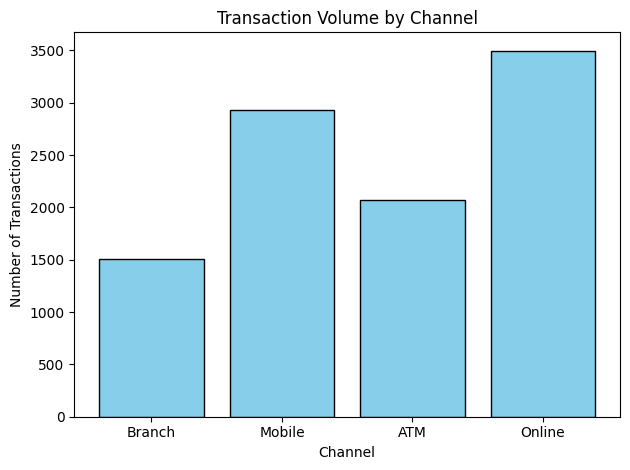

In [67]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df['Channel'],
        df['Transactions_count'],
        color ='skyblue',
        edgecolor ='black'
        )
plt.title("Transaction Volume by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

df = pd.read_csv('/content/Capstone_combine_Transactions.csv')

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Clean column names
df.columns = df.columns.str.strip()

# Convert amount to numeric and drop invalid rows
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['Amount'])

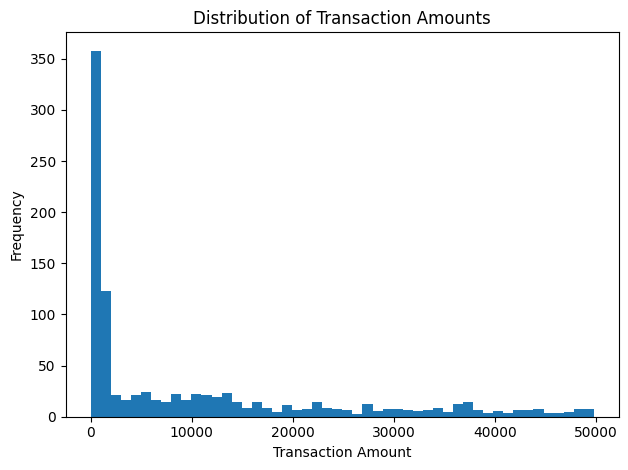

In [56]:
plt.figure()
plt.hist(df['Amount'], bins=50)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

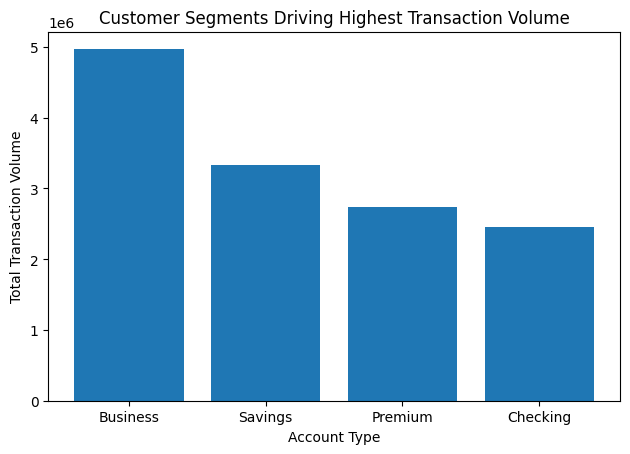

High-Volume Customer Segment Summary:


,Account_Type,High_Volume_Customers,Total_Volume
0,Business,39,4970789.25
3,Savings,24,3332234.66
2,Premium,21,2740951.15
1,Checking,19,2456694.23


In [57]:
# 1 Calculate total volume per CUSTOMER
customer_volume = (
    df.groupby('Customer_ID')
      .agg(
          Total_Volume=('Amount', 'sum'),
          Transaction_Count=('Amount', 'count')
      )
      .reset_index()
)

# 2 Identify high-volume customers (Top 20%)
volume_threshold = customer_volume['Total_Volume'].quantile(0.80)
customer_volume['High_Volume_Flag'] = (
    customer_volume['Total_Volume'] >= volume_threshold
)

# 3 Attach customer segments
customer_segments = (
    df[['Customer_ID', 'Account_Type', 'City', 'Channel']]
    .drop_duplicates()
)

customer_analysis = customer_volume.merge(
    customer_segments,
    on='Customer_ID',
    how='left'
)

# 4 Segment analysis: Account Type
segment_summary = (
    customer_analysis[customer_analysis['High_Volume_Flag']]
    .groupby('Account_Type')
    .agg(
        High_Volume_Customers=('Customer_ID', 'count'),
        Total_Volume=('Total_Volume', 'sum')
    )
    .reset_index()
    .sort_values(by='Total_Volume', ascending=False)
)
# 5 Visualization
plt.figure()
plt.bar(segment_summary['Account_Type'], segment_summary['Total_Volume'])
plt.title("Customer Segments Driving Highest Transaction Volume")
plt.xlabel("Account Type")
plt.ylabel("Total Transaction Volume")
plt.tight_layout()
plt.show()

# 6 Output results
print("High-Volume Customer Segment Summary:")
display(segment_summary)



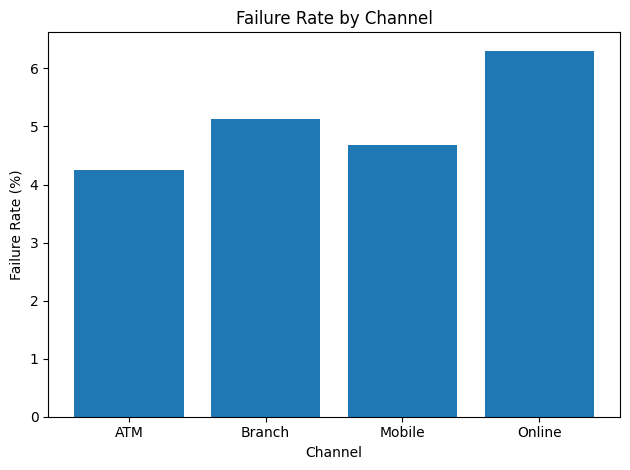

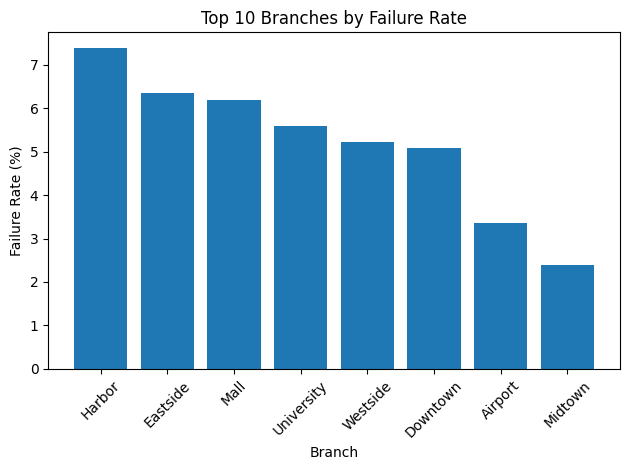

Overall Status Breakdown:


,Status,Transaction_Count
0,Completed,834
1,Failed,52
2,Pending,114


Failure Rate by Channel:


Status,Channel,Completed,Failed,Pending,Total,Failure_Rate_%
0,ATM,181,9,22,212,4.245283
1,Branch,133,8,15,156,5.128205
2,Mobile,252,14,33,299,4.682274
3,Online,268,21,44,333,6.306306


Top 10 Branches with Highest Failure Rate:


Status,Branch,Completed,Failed,Pending,Total,Failure_Rate_%
0,Harbor,102,9,11,122,7.377049
1,Eastside,119,9,14,142,6.338028
2,Mall,89,7,17,113,6.194690
3,University,105,7,13,125,5.600000
4,Westside,95,6,14,115,5.217391
5,Downtown,114,7,17,138,5.072464
6,Airport,102,4,13,119,3.361345
7,Midtown,108,3,15,126,2.380952


In [58]:
# 1 Overall failure rate
overall = (
    df.groupby('Status')
      .size()
      .reset_index(name='Transaction_Count')
)

# 2 Failure rate by Channel
channel_summary = (
    df.groupby(['Channel', 'Status'])
      .size()
      .reset_index(name='Count')
)

channel_pivot = channel_summary.pivot(
    index='Channel',
    columns='Status',
    values='Count'
).fillna(0)

channel_pivot['Total'] = channel_pivot.sum(axis=1)
channel_pivot['Failure_Rate_%'] = (
    channel_pivot.get('Failed', 0) / channel_pivot['Total']
) * 100

# 3 Failure rate by Branch
branch_summary = (
    df.groupby(['Branch', 'Status'])
      .size()
      .reset_index(name='Count')
)
branch_pivot = branch_summary.pivot(
    index='Branch',
    columns='Status',
    values='Count'
).fillna(0)

branch_pivot['Total'] = branch_pivot.sum(axis=1)
branch_pivot['Failure_Rate_%'] = (
    branch_pivot.get('Failed', 0) / branch_pivot['Total']
) * 100

branch_pivot = branch_pivot.sort_values(
    by='Failure_Rate_%',
    ascending=False
)

# 4 Visualizations
plt.figure()
plt.bar(channel_pivot.index, channel_pivot['Failure_Rate_%'])
plt.title("Failure Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(branch_pivot.head(10).index, branch_pivot.head(10)['Failure_Rate_%'])
plt.title("Top 10 Branches by Failure Rate")
plt.xlabel("Branch")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5 Display tables
print("Overall Status Breakdown:")
display(overall)

print("Failure Rate by Channel:")
display(channel_pivot.reset_index())

print("Top 10 Branches with Highest Failure Rate:")
display(branch_pivot.head(10).reset_index())


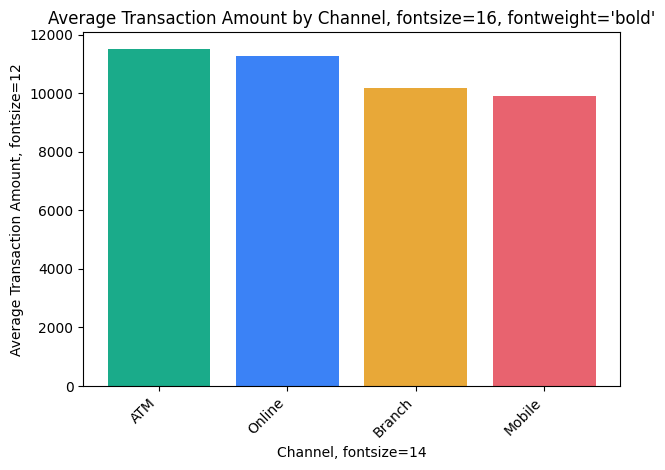

<Figure size 640x480 with 0 Axes>

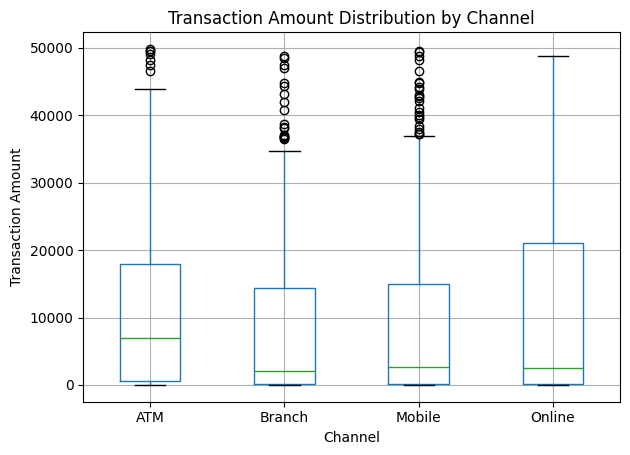

Transaction Amount Summary by Channel:


,Channel,Transaction_Count,Avg_Amount,Median_Amount,Total_Volume
0,ATM,212,11499.181038,6894.215,2437826.38
3,Online,333,11261.081502,2568.650,3749940.14
1,Branch,156,10158.265064,2085.250,1584689.35
2,Mobile,299,9914.878528,2621.380,2964548.68


In [59]:
# 1 Summary statistics by Channel
channel_amount_summary = (
    df.groupby('Channel')
      .agg(
          Transaction_Count=('Amount', 'count'),
          Avg_Amount=('Amount', 'mean'),
          Median_Amount=('Amount', 'median'),
          Total_Volume=('Amount', 'sum')
      )
      .reset_index()
      .sort_values(by='Avg_Amount', ascending=False)
)

# 2 Bar chart: Average transaction amount by Channel
plt.figure()
plt.bar(channel_amount_summary['Channel'], channel_amount_summary['Avg_Amount'] ,color=['#1AAB8A', '#3B82F6', '#E8A838', '#E8636F'])
plt.title("Average Transaction Amount by Channel, fontsize=16, fontweight='bold'")
plt.xlabel("Channel, fontsize=14")
plt.ylabel("Average Transaction Amount, fontsize=12")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3 Boxplot: Distribution of amounts by Channel
plt.figure()
df.boxplot(column='Amount', by='Channel')
plt.title("Transaction Amount Distribution by Channel")
plt.suptitle("")
plt.xlabel("Channel")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

# 4 Output summary table
print("Transaction Amount Summary by Channel:")
display(channel_amount_summary)

In [60]:
# 1 Ensure Amount is numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['Amount'])

# 2 Calculate each customer's average transaction amount
customer_avg = (
    df.groupby('Customer_ID')['Amount']
      .mean()
      .reset_index()
      .rename(columns={'Amount': 'Customer_Avg_Amount'})
)

# 3 Merge average back to transaction-level data
df_flagged = df.merge(
    customer_avg,
    on='Customer_ID',
    how='left'
)

# 4 Flag suspicious transactions
df_flagged['Suspicious_Flag'] = (
    df_flagged['Amount'] > 3 * df_flagged['Customer_Avg_Amount']
)

# 5 View suspicious transactions
suspicious_transactions = df_flagged[df_flagged['Suspicious_Flag'] == True]

print("Number of Suspicious Transactions:")
print(len(suspicious_transactions))

suspicious_transactions.head()

Number of Suspicious Transactions:
86


,Transaction_ID,Transaction_Date,Amount,Channel,Transaction_Type,Branch,Status,Customer_ID,Customer_Name,City,Account_Type,Account_Open_Date,Customer_Avg_Amount,Suspicious_Flag
3,TXN-013140,2025-08-10,37111.82,Online,Withdrawal,Eastside,Completed,CUST-1000,Valentina Martin,New York,Business,2019-04-05,7304.326667,True
14,TXN-016891,2025-09-06,29090.19,Mobile,Withdrawal,Eastside,Completed,CUST-1001,Bao Harris,Istanbul,Savings,2022-07-02,7982.082857,True
29,TXN-019620,2025-08-16,43748.65,Online,Fee,Mall,Completed,CUST-1003,Zainab Schmidt,Manila,Premium,2019-08-19,12070.158000,True
46,TXN-013822,2025-10-09,37640.36,Online,Transfer,Westside,Completed,CUST-1006,Tyler Sharma,Moscow,Business,2022-05-26,6710.574444,True
55,TXN-018594,2025-01-20,32330.15,ATM,Payment,Airport,Completed,CUST-1007,Linda Joshi,Stockholm,Savings,2021-02-18,9969.354286,True


In [61]:
# 1 Convert date column
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# 2 Daily transaction count per customer
daily_activity = (
    df.groupby(['Customer_ID', 'Transaction_Date'])
      .size()
      .reset_index(name='Daily_Transaction_Count')
)

# 3 Average daily activity per customer
customer_avg_activity = (
    daily_activity.groupby('Customer_ID')['Daily_Transaction_Count']
    .mean()
    .reset_index()
    .rename(columns={'Daily_Transaction_Count': 'Avg_Daily_Transactions'})
)

# 4 Merge averages back
activity_analysis = daily_activity.merge(
    customer_avg_activity,
    on='Customer_ID',
    how='left'
)

#5 Flag sudden spikes (3× normal activity)
activity_analysis['Spike_Flag'] = (
    activity_analysis['Daily_Transaction_Count'] >
    3 * activity_analysis['Avg_Daily_Transactions']
)

# 6 Extract suspicious spikes
spike_accounts = activity_analysis[activity_analysis['Spike_Flag'] == True]

print("Number of spike events detected:")
print(len(spike_accounts))

spike_accounts.head()

Number of spike events detected:
0


,Customer_ID,Transaction_Date,Daily_Transaction_Count,Avg_Daily_Transactions,Spike_Flag


In [62]:
# Ensure correct types
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Sort data
df = df.sort_values(['Customer_ID', 'Transaction_Date'])

# Split timeline: earlier vs recent (50%-50%)
df['Period'] = df.groupby('Customer_ID').cumcount() / \
               df.groupby('Customer_ID')['Transaction_Date'].transform('count')

df['Period'] = df['Period'].apply(lambda x: 'Past' if x < 0.5 else 'Recent')

# Aggregate behavior
summary = (
    df.groupby(['Customer_ID', 'Period'])
      .agg(
          Avg_Amount=('Amount', 'mean'),
          Txn_Count=('Amount', 'count')
      )
      .reset_index()
)

# Pivot for comparison
pivot = summary.pivot(index='Customer_ID', columns='Period')

# Flatten columns
pivot.columns = ['_'.join(col) for col in pivot.columns]
pivot = pivot.reset_index()

# Calculate percentage change
pivot['Amount_Change_%'] = (
    (pivot['Avg_Amount_Recent'] - pivot['Avg_Amount_Past']) /
    pivot['Avg_Amount_Past']
) * 100

pivot['Txn_Count_Change_%'] = (
    (pivot['Txn_Count_Recent'] - pivot['Txn_Count_Past']) /
    pivot['Txn_Count_Past']
) * 100

# Flag significant behavior change
pivot['Behavior_Changed'] = (
    (pivot['Amount_Change_%'] >= 50) |
    (pivot['Txn_Count_Change_%'] >= 50)
)
print("Number of Behavior_Changed:")
print(len('Behavior_Changed'))

# Final flagged customers
behavior_change_df = pivot[pivot['Behavior_Changed']]

behavior_change_df

Number of Behavior_Changed:
16


,Customer_ID,Avg_Amount_Past,Avg_Amount_Recent,Txn_Count_Past,Txn_Count_Recent,Amount_Change_%,Txn_Count_Change_%,Behavior_Changed
0,CUST-1000,4424.932000,10903.570000,5,4,146.412148,-20.000000,True
2,CUST-1002,4006.500000,11222.995000,2,2,180.119681,0.000000,True
3,CUST-1003,8229.118000,15911.198000,5,5,93.352410,0.000000,True
6,CUST-1006,2453.614000,12031.775000,5,4,390.369512,-20.000000,True
11,CUST-1011,4032.902500,7774.740000,4,3,92.782741,-25.000000,True
15,CUST-1015,4551.826667,22511.610000,3,3,394.562110,0.000000,True
17,CUST-1017,6135.263333,15917.936667,3,3,159.449934,0.000000,True
24,CUST-1024,4899.245000,31818.280000,2,2,549.452722,0.000000,True
25,CUST-1025,449.357500,4531.593333,4,3,908.460598,-25.000000,True
33,CUST-1033,4526.222500,8362.540000,4,3,84.757599,-25.000000,True


In [63]:
# Ensure correct types
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# -------------------------------
# 1. Customer baseline metrics
# -------------------------------
baseline = (
    df.groupby('Customer_ID')
      .agg(
          Avg_Amount=('Amount', 'mean'),
          Total_Amount=('Amount', 'sum'),
          Txn_Count=('Amount', 'count')
      )
      .reset_index()
)

# -------------------------------
# 2. Large transaction anomaly (3x avg)
# -------------------------------
df = df.merge(baseline[['Customer_ID', 'Avg_Amount']], on='Customer_ID')

df['Large_Anomaly'] = df['Amount'] > (3 * df['Avg_Amount'])

large_anomaly_flag = (
    df.groupby('Customer_ID')['Large_Anomaly']
      .any()
      .reset_index()
)

# -------------------------------
# 3. Frequency spike detection
# -------------------------------
df['Txn_Month'] = df['Transaction_Date'].dt.to_period('M')

monthly_freq = (
    df.groupby(['Customer_ID', 'Txn_Month'])
      .size()
      .reset_index(name='Monthly_Txn')
)
freq_stats = (
    monthly_freq.groupby('Customer_ID')['Monthly_Txn']
    .mean()
    .reset_index(name='Avg_Monthly_Txn')
)

monthly_freq = monthly_freq.merge(freq_stats, on='Customer_ID')
monthly_freq['Freq_Spike'] = monthly_freq['Monthly_Txn'] > (2 * monthly_freq['Avg_Monthly_Txn'])

freq_spike_flag = (
    monthly_freq.groupby('Customer_ID')['Freq_Spike']
    .any()
    .reset_index()
)

# -------------------------------
# 4. Behavior change (from earlier analysis)
# -------------------------------
df = df.sort_values(['Customer_ID', 'Transaction_Date'])
df['Period'] = df.groupby('Customer_ID').cumcount() / \
               df.groupby('Customer_ID')['Transaction_Date'].transform('count')

df['Period'] = df['Period'].apply(lambda x: 'Past' if x < 0.5 else 'Recent')

behavior = (
    df.groupby(['Customer_ID', 'Period'])
      .agg(
          Avg_Amount=('Amount', 'mean'),
          Txn_Count=('Amount', 'count')
      )
      .reset_index()
)
behavior = behavior.pivot(index='Customer_ID', columns='Period')
behavior.columns = ['_'.join(col) for col in behavior.columns]
behavior = behavior.reset_index()

behavior['Behavior_Changed'] = (
    ((behavior['Avg_Amount_Recent'] - behavior['Avg_Amount_Past']) /
     behavior['Avg_Amount_Past'] >= 0.5) |
    ((behavior['Txn_Count_Recent'] - behavior['Txn_Count_Past']) /
     behavior['Txn_Count_Past'] >= 0.5)
)

# -------------------------------
# 5. Combine all risk signals
# -------------------------------
risk_df = baseline.merge(large_anomaly_flag, on='Customer_ID') \
                  .merge(freq_spike_flag, on='Customer_ID') \
                  .merge(behavior[['Customer_ID', 'Behavior_Changed']], on='Customer_ID')

# -------------------------------
# 6. Fraud Risk Score
# -------------------------------
risk_df['Risk_Score'] = (
    risk_df['Behavior_Changed'].astype(int) * 3 +
    risk_df['Large_Anomaly'].astype(int) * 2 +
    risk_df['Freq_Spike'].astype(int) * 2 +
    (risk_df['Total_Amount'] > risk_df['Total_Amount'].median()).astype(int)
)

# -------------------------------
# 7. PRIORITIZED ESCALATION LIST
# -------------------------------
escalation_list = (
    risk_df.sort_values('Risk_Score', ascending=False)
           .query('Risk_Score >= 3')
)
escalation_list

,Customer_ID,Avg_Amount,Total_Amount,Txn_Count,Large_Anomaly,Freq_Spike,Behavior_Changed,Risk_Score
97,CUST-1097,8258.934545,90848.28,11,True,True,True,8
44,CUST-1044,10447.246250,83577.97,8,True,False,True,6
75,CUST-1075,9595.019000,95950.19,10,True,False,True,6
42,CUST-1042,9921.410000,69449.87,7,True,False,True,6
3,CUST-1003,12070.158000,120701.58,10,True,False,True,6
...,...,...,...,...,...,...,...,...
144,CUST-1144,10819.316667,129831.80,12,True,False,False,3
132,CUST-1132,12327.872000,123278.72,10,True,False,False,3
139,CUST-1139,21897.003333,65691.01,3,False,False,True,3
147,CUST-1147,1633.626667,9801.76,6,False,False,True,3


In [64]:
with pd.ExcelWriter("Fraud_Analysis_Report.xlsx") as writer:
    df.to_excel(writer, sheet_name="All_Transactions", index=False)
    escalation_list.to_excel(writer, sheet_name="Flagged_Accounts", index=False)